In [1]:
# import libraries

import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("queue_dataset.csv")
df

,Service_Type,Department,Current_Queue,Available_Staff,Emergency_Cases,Previous_Average_Wait,Day,Hour,Waiting_Time
0,Hospital,General,56,13,14,47,Tuesday,14,58
1,Government Office,General,87,7,10,15,Monday,17,55
2,Hospital,Loan Department,104,8,23,7,Monday,15,87
3,Government Office,Emergency,25,1,11,26,Tuesday,19,41
4,Hospital,Emergency,112,9,16,31,Wednesday,20,67
...,...,...,...,...,...,...,...,...,...
4995,Hospital,Emergency,112,1,10,40,Wednesday,12,98
4996,Hospital,Loan Department,70,2,23,21,Wednesday,10,73
4997,Hospital,General,70,14,3,54,Monday,14,45
4998,Hospital,Loan Department,70,2,17,21,Saturday,16,81


In [3]:
df.shape

(5000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Service_Type           5000 non-null   object
 1   Department             5000 non-null   object
 2   Current_Queue          5000 non-null   int64 
 3   Available_Staff        5000 non-null   int64 
 4   Emergency_Cases        5000 non-null   int64 
 5   Previous_Average_Wait  5000 non-null   int64 
 6   Day                    5000 non-null   object
 7   Hour                   5000 non-null   int64 
 8   Waiting_Time           5000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 351.7+ KB


In [5]:
df.columns

Index(['Service_Type', 'Department', 'Current_Queue', 'Available_Staff',
       'Emergency_Cases', 'Previous_Average_Wait', 'Day', 'Hour',
       'Waiting_Time'],
      dtype='object')

# Exploratory Data Analysis (EDA)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df.head()

,Service_Type,Department,Current_Queue,Available_Staff,Emergency_Cases,Previous_Average_Wait,Day,Hour,Waiting_Time
0,Hospital,General,56,13,14,47,Tuesday,14,58
1,Government Office,General,87,7,10,15,Monday,17,55
2,Hospital,Loan Department,104,8,23,7,Monday,15,87
3,Government Office,Emergency,25,1,11,26,Tuesday,19,41
4,Hospital,Emergency,112,9,16,31,Wednesday,20,67


In [8]:
df.describe()

,Current_Queue,Available_Staff,Emergency_Cases,Previous_Average_Wait,Hour,Waiting_Time
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,61.560800,7.373000,11.957200,32.013600,14.051000,51.609600
std,33.289096,4.051315,7.151587,15.797776,3.768719,23.161979
min,5.000000,1.000000,0.000000,5.000000,8.000000,5.000000
25%,32.000000,4.000000,6.000000,18.000000,11.000000,35.000000
50%,61.000000,7.000000,12.000000,32.000000,14.000000,51.000000
75%,91.000000,11.000000,18.000000,46.000000,17.000000,68.000000
max,119.000000,14.000000,24.000000,59.000000,20.000000,121.000000


In [9]:
df.isnull().sum()

,0
Service_Type,0
Department,0
Current_Queue,0
Available_Staff,0
Emergency_Cases,0
Previous_Average_Wait,0
Day,0
Hour,0
Waiting_Time,0


In [10]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

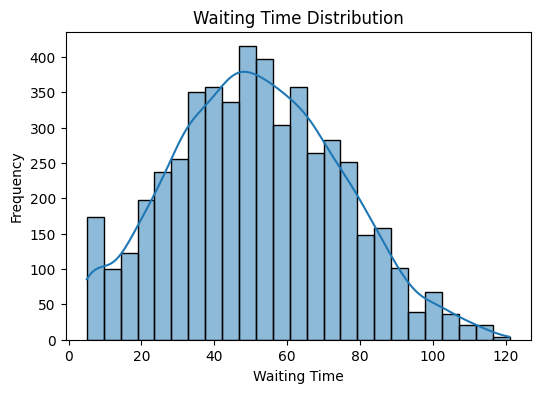

In [11]:
# Waiting Time Distribution

plt.figure(figsize=(6,4))

sns.histplot(df["Waiting_Time"], bins=25, kde=True)

plt.title("Waiting Time Distribution")
plt.xlabel("Waiting Time")
plt.ylabel("Frequency")

plt.show()

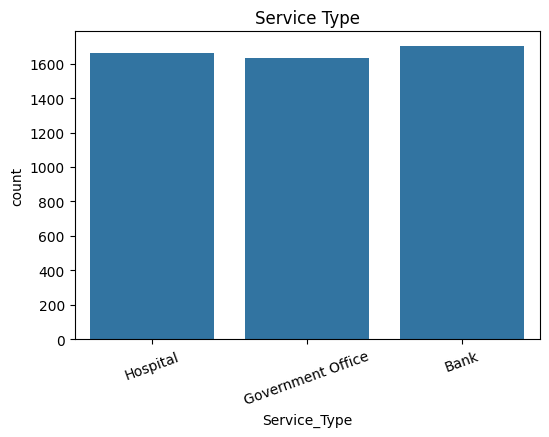

In [12]:
# Service Type

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Service_Type")

plt.title("Service Type")

plt.xticks(rotation=20)

plt.show()

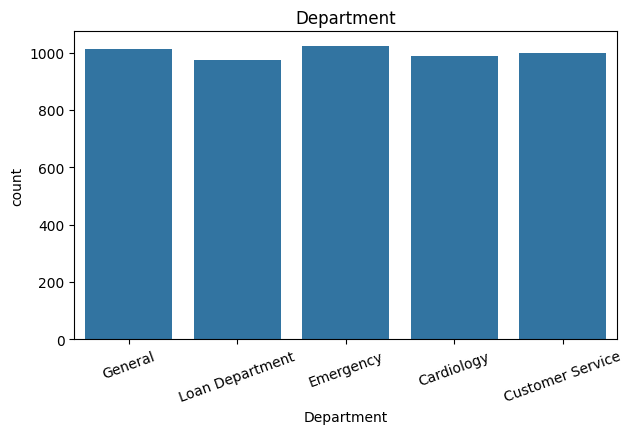

In [13]:
# Department

plt.figure(figsize=(7,4))

sns.countplot(data=df, x="Department")

plt.title("Department")

plt.xticks(rotation=20)

plt.show()

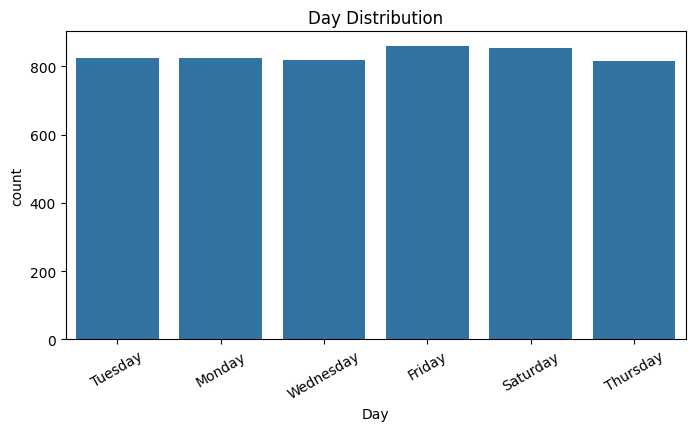

In [14]:
# Day Distribution

plt.figure(figsize=(8,4))

sns.countplot(data=df, x="Day")

plt.title("Day Distribution")

plt.xticks(rotation=30)

plt.show()

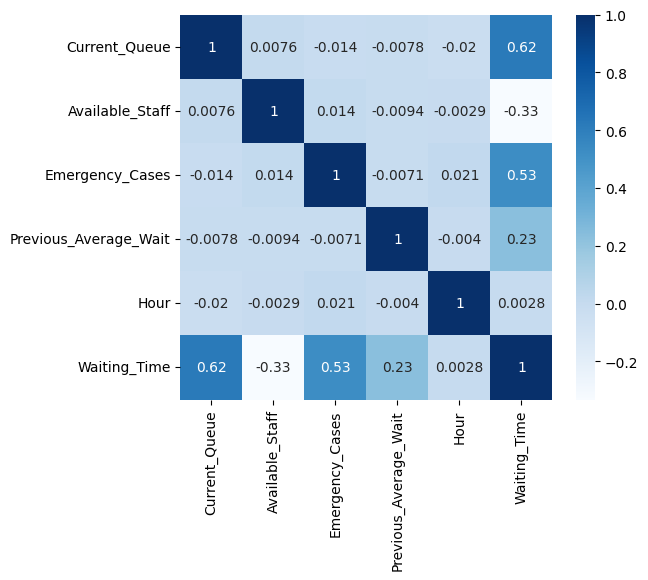

In [15]:
# Correlation Matrix

plt.figure(figsize=(6,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.show()

# Data Preprocessing + Feature Engineering

In [16]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Service_Type"] = le.fit_transform(df["Service_Type"])
df["Department"] = le.fit_transform(df["Department"])
df["Day"] = le.fit_transform(df["Day"])

df.head()

,Service_Type,Department,Current_Queue,Available_Staff,Emergency_Cases,Previous_Average_Wait,Day,Hour,Waiting_Time
0,2,3,56,13,14,47,4,14,58
1,1,3,87,7,10,15,1,17,55
2,2,4,104,8,23,7,1,15,87
3,1,2,25,1,11,26,4,19,41
4,2,2,112,9,16,31,5,20,67


In [17]:
# Features and Target

X = df.drop("Waiting_Time", axis=1)

y = df["Waiting_Time"]

print(X.shape)
print(y.shape)

(5000, 8)
(5000,)


In [18]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(4000, 8)
(1000, 8)


In [19]:
# Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [20]:
lr_pred = lr.predict(X_test)

In [21]:
# Import Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [22]:
mae = mean_absolute_error(y_test, lr_pred)
mse = mean_squared_error(y_test, lr_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, lr_pred)
print("Linear Regression")
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,2))

Linear Regression
MAE : 7.75
RMSE : 9.08
R2 Score : 0.86


In [23]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [24]:
dt_pred = dt.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, dt_pred)
mse = mean_squared_error(y_test, dt_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, dt_pred)
print("Decision Tree")
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,2))

Decision Tree
MAE : 8.57
RMSE : 10.86
R2 Score : 0.79


In [26]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

RandomForestRegressor()

In [27]:
rf_pred = rf.predict(X_test)

In [28]:
mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, rf_pred)
print("Random Forest")
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,2))

Random Forest
MAE : 5.62
RMSE : 6.93
R2 Score : 0.92


In [29]:
# Model Comparison

Model_Comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],

    "RMSE": [
        mean_squared_error(y_test, lr_pred) ** 0.5,
        mean_squared_error(y_test, dt_pred) ** 0.5,
        mean_squared_error(y_test, rf_pred) ** 0.5
    ],

    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]

})

Model_Comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,7.749499,9.079956,0.855061
1,Decision Tree,8.571000,10.862274,0.792576
2,Random Forest,5.615870,6.930783,0.915553


In [30]:
# Best Model

Model_Comparison.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest,5.615870,6.930783,0.915553
0,Linear Regression,7.749499,9.079956,0.855061
1,Decision Tree,8.571000,10.862274,0.792576


In [31]:
# Save Model

import joblib

joblib.dump(rf, "queue_predictor.pkl")

print("Model Saved Successfully")

Model Saved Successfully
